In [1]:
from pathlib import Path
import pandas as pd

source = Path("/media/storage/gepner/derivatives/kepost")

In [2]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
DATA_DIR = Path("/home/galkepler/Projects/neuroaging/data")

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [48]:
data = []
for fname in source.glob("sub-*/ses-*/dwi/software-mrtrix3/subtype-parcellations/atlas-schaefer2018tian2020_div-7networks_den-400/sub-*_ses-*_acq-shell1000_space-MNI152NLin2009cAsym_atlas-schaefer2018tian2020_div-7networks_den-400_meas-adc_parc.pkl"):
    subj_df = pd.read_pickle(fname)
    data.append(subj_df)
df = pd.concat(data)

behav = pd.read_excel(DATA_DIR / "external" / "ARE_data_for_Gal.xlsx")
behav = behav.rename(columns={"Wt_pre": "WT_pre"})
behav["subject_code"] = behav["sno"].astype(str).str.zfill(2)

df = pd.merge(df, behav, on="subject_code", how="left")
# keep only subject_codes with more than 1 session
s = df.drop_duplicates(subset=["subject_code", "session_id"],keep="first")
counts = s["subject_code"].value_counts()
keep = counts[counts > 1].index
df = df[df["subject_code"].isin(keep)]

# prepare to t test
df = df.sort_values(by=["subject_code", "session_id"])
# add "session_tag" columns (e.g,, for each subject, session 1 is 1, session 2 is 2, etc.)
for subject in df["subject_code"].unique():
    # get subject's session_ids
    subject_sessions = df[df["subject_code"] == subject]["session_id"].unique()
    # assign session_tag based on session_id order
    session_tag = {session_id: i + 1 for i, session_id in enumerate(subject_sessions)}
    # map session_tag to the dataframe
    df.loc[df["subject_code"] == subject, "session_tag"] = df[df["subject_code"] == subject]["session_id"].map(session_tag)
before = df.groupby(["index","subject_code"]).first().reset_index()
after = df.groupby(["index","subject_code"]).last().reset_index()
df["session_tag"] = df["session_tag"].astype(int).astype(str)

In [83]:
# do mixed linear model
from statsmodels.formula.api import ols, mixedlm
import statsmodels.api as sm
import warnings
from tqdm import tqdm
warnings.filterwarnings("ignore", module="statsmodels")

dist_measure = "qfmean"

stats = parcels.copy()

for i, row in tqdm(parcels.iterrows(), total=len(parcels), desc="Running mixed linear model"):
    roi = row[region_col]
    roi_data = df[df[region_col] == roi]
    # run mixed linear model
    model = mixedlm(f"{dist_measure} ~ Age + C(Gender) +C(Gender) + C(session_tag)", roi_data, groups=roi_data["subject_code"])
    result = model.fit()
    stats.loc[i, "beta"] = result.params["C(session_tag)[T.2]"]
    stats.loc[i, "t_stat"] = result.tvalues["C(session_tag)[T.2]"]
    stats.loc[i, "p_val"] = result.pvalues["C(session_tag)[T.2]"]
    # break

Running mixed linear model: 100%|██████████| 454/454 [00:09<00:00, 45.82it/s]


In [49]:
reg_cols = ["Kidneys_del","Liver_del","RMR_del","TDEE_del","WT_del"]
df_rel = df.drop_duplicates(subset=["index", "subject_code"], keep="first")
df_rel[dist_measure] = (after[dist_measure].values - before[dist_measure].values) / before[dist_measure].values
for reg_col in reg_cols:
    df_rel[reg_col.replace("_del","_rel_del")] = (df_rel[reg_col.replace("_del","_post")].values / df_rel[reg_col.replace("_del","_pre")].values) / df_rel[reg_col.replace("_del","_pre")].values

/tmp/ipykernel_2486862/3248936424.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rel[dist_measure] = (after[dist_measure].values - before[dist_measure].values) / before[dist_measure].values
/tmp/ipykernel_2486862/3248936424.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rel[reg_col.replace("_del","_rel_del")] = (df_rel[reg_col.replace("_del","_post")].values / df_rel[reg_col.replace("_del","_pre")].values) / df_rel[reg_col.replace("_del","_pre")].values
/tmp/ipykernel_2486862/3248936424.py:5

In [75]:
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests

reg_stats = {}

for reg_col in reg_cols:
    rel_reg_col = reg_col.replace("_del", "_rel_del")
    cur_stats = parcels.copy()
    for i, row in tqdm(parcels.iterrows(), total=len(parcels), desc=f"Running linear model for {reg_col}"):
        roi = row[region_col]
        roi_data = df_rel[df_rel[region_col] == roi]
        # run mixed linear model
        model = ols(f"{dist_measure} ~ {rel_reg_col} + Age", data=roi_data)
        result = model.fit()
        cur_stats.loc[i, "beta"] = result.params[rel_reg_col]
        cur_stats.loc[i, "t_stat"] = result.tvalues[rel_reg_col]
        cur_stats.loc[i, "p_val"] = result.pvalues[rel_reg_col]
        cur_stats.loc[i, "r2"] = result.rsquared
        cur_stats.loc[i, "adj_r2"] = result.rsquared_adj
        cur_stats.loc[i,"model_pval"] = result.f_pvalue
    cur_stats["p_val_adj"] = multipletests(cur_stats["p_val"], method="fdr_bh")[1]
    reg_stats[reg_col] = cur_stats
    # break

Running linear model for WT_del: 100%|██████████| 454/454 [00:01<00:00, 255.38it/s]


In [93]:
print(f'{stats.sort_values(by="p_val").iloc[0]["p_val"]:.2e}')

6.68e-04


In [58]:
from scipy.stats import ttest_rel

dist_measure = "qfmean"

stats_t_test = parcels.copy()

for i,row in parcels.iterrows():
    roi = row[region_col]
    before_roi = before[before[region_col] == roi][dist_measure].values
    after_roi = after[after[region_col] == roi][dist_measure].values
    if len(before_roi) == 0 or len(after_roi) == 0:
        continue
    t_stat, p_val = ttest_rel(after_roi,before_roi)
    stats_t_test.loc[i, "t_stat"] = t_stat
    stats_t_test.loc[i, "p_val"] = p_val

In [84]:
stats["pval_adj"] = multipletests(stats["p_val"], method="fdr_bh")[1]
stats_t_test["pval_adj"] = multipletests(stats_t_test["p_val"], method="fdr_bh")[1]

reg_stats["t_test"] = stats_t_test
reg_stats["mixedlm"] = stats

In [85]:
stats.sort_values(by="p_val").head(20)

,index,name,base_name,Label Name,network,component,hemisphere,beta,t_stat,p_val,pval_adj
256,257,7Networks_RH_SomMot_27,7networks_rh_sommot,7Networks_RH_SomMot,somatomotor,somatomotor,R,0.000031,3.402513,0.000668,0.170808
355,356,7Networks_RH_Cont_pCun_1,7networks_rh_cont_pcun,7Networks_RH_Cont_pCun,control,precuneus,R,0.000018,3.369715,0.000752,0.170808
275,276,7Networks_RH_DorsAttn_Post_6,7networks_rh_dorsattn_post,7Networks_RH_DorsAttn_Post,dorsal attention,posterior,R,0.000017,3.056932,0.002236,0.218115
126,127,7Networks_LH_Cont_Par_1,7networks_lh_cont_par,7Networks_LH_Cont_Par,control,parietal,L,0.000017,3.056773,0.002237,0.218115
198,199,7Networks_LH_Default_pCunPCC_10,7networks_lh_default_pcunpcc,7Networks_LH_Default_pCunPCC,default,precuneus posterior cingulate cortex,L,0.000012,2.992753,0.002765,0.218115
96,97,7Networks_LH_SalVentAttn_FrOperIns_1,7networks_lh_salventattn_froperins,7Networks_LH_SalVentAttn_FrOperIns,salience / ventral attention,frontal operculum insula,L,0.000015,2.892942,0.003817,0.218115
436,437,THA-VAs-lh,THA-VAs,"Thalamus, superior ventro-anterior part",subcortex,Thalamus,L,0.000014,2.854156,0.004315,0.218115
280,281,7Networks_RH_DorsAttn_Post_11,7networks_rh_dorsattn_post,7Networks_RH_DorsAttn_Post,dorsal attention,posterior,R,0.000012,2.847199,0.004411,0.218115
191,192,7Networks_LH_Default_pCunPCC_3,7networks_lh_default_pcunpcc,7Networks_LH_Default_pCunPCC,default,precuneus posterior cingulate cortex,L,0.000017,2.845263,0.004437,0.218115
266,267,7Networks_RH_SomMot_37,7networks_rh_sommot,7Networks_RH_SomMot,somatomotor,somatomotor,R,0.000022,2.687173,0.007206,0.218115


In [80]:
# 3.  Helper function for consistent figure export
def savefig_nice(fig, filename, *, tight=True, dpi=300, **savefig_kwargs):
    """Save figure with tight layout and correct DPI."""
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight", transparent=True, **savefig_kwargs)

In [86]:
import numpy as np
import pandas as pd
import nibabel as nb
from nilearn import surface, datasets
from surfplot import Plot
from matplotlib.colors import TwoSlopeNorm  # nice diverging colours
from neuromaps.datasets import fetch_fslr
from brainspace.datasets import load_parcellation
import nibabel as nib


atlas_img = nib.load(nifti_matlab)

# ---------------------------------------------------------------------
# 2.  FETCH A STANDARD SURFACE  (fsaverage5 = 10k vertices per hemi)
# ---------------------------------------------------------------------
surfaces = fetch_fslr()
lh, rh = surfaces["veryinflated"]


# ---------------------------------------------------------------------
# 3.  SAMPLE ATLAS VOXELS → SURFACE  (nearest-neighbour so labels stay int)
# ---------------------------------------------------------------------
# add schaefer parcellation (no color bar needed)
lh_parc, rh_parc = load_parcellation("schaefer")

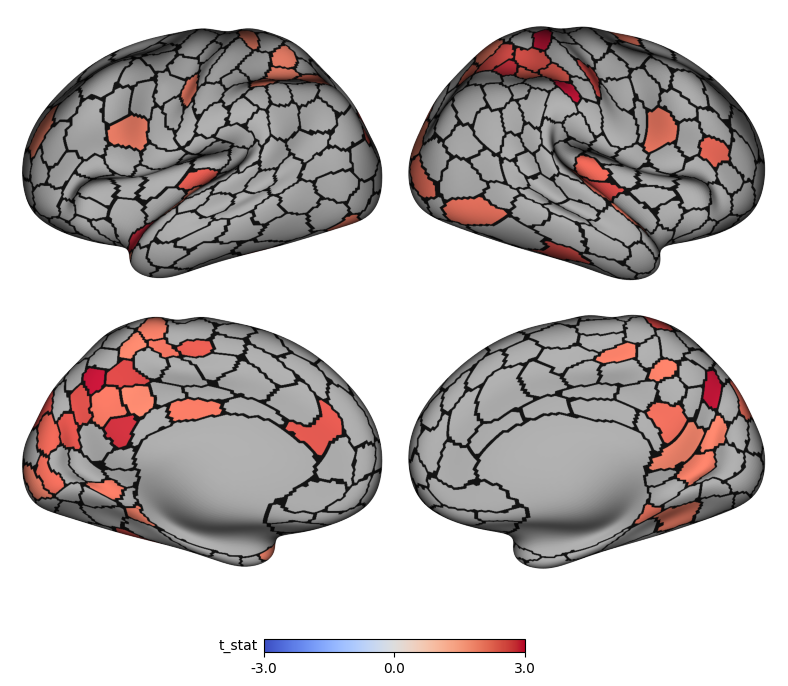

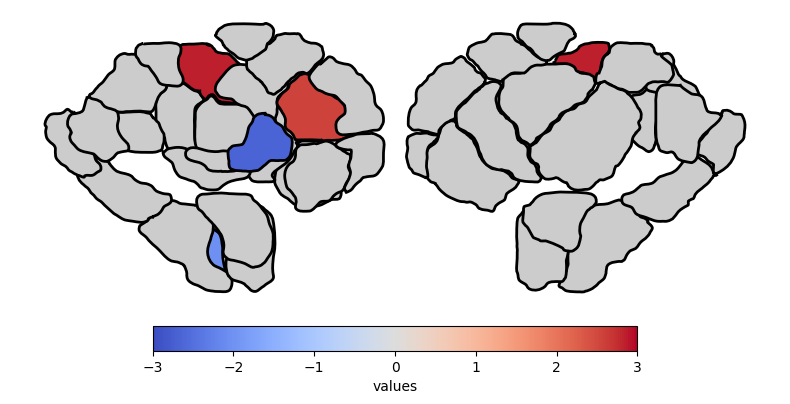

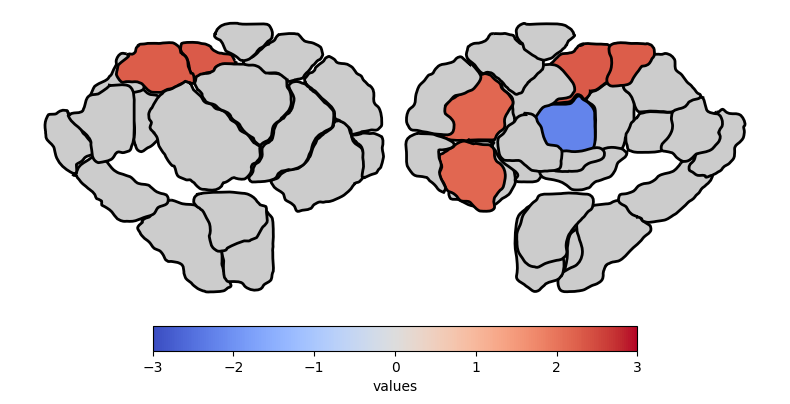

In [87]:
from subcortex_visualization.plotting import plot_subcortical_data
# ---------------------------------------------------------------------
# 4.  MAP REGION IDs → METRIC VALUES
#     vertices with label 0 (background) → NaN so they render transparent
# ---------------------------------------------------------------------
p_threshold = 0.05
value_threshold = 0

value_map = {}
value_map_subcortex = {"region": [], "value": [], "Hemisphere": []}

vmin = -3
vmax = 3

for col, vis_df in reg_stats.items():
    if col != "mixedlm":
        continue

# vis_df = stats.copy()
    p_column = "p_val"
    value_column = "t_stat"

    value_map_lh = {}  # New: separate map for left hemisphere
    value_map_rh = {}  # New: separate map for right hemisphere

    for i, row in vis_df.iterrows():
        label = row[region_col]
        hemi_row = row["hemisphere"]  # Get hemisphere from your DataFrame row

        # Apply thresholds
        if (row[p_column] < p_threshold) and (np.abs(row[value_column]) > value_threshold):
            value = row[value_column]
        else:
            value = np.nan  # Set to NaN if not significant or below value_threshold

        # Populate the correct hemisphere's value_map
        # Assuming your labels are global and you use the 'hemisphere' column to distinguish
        # If your Schaefer labels are already separated by hemi (e.g., 1-200 for LH, 201-400 for RH)
        # then you might only need to check the label range and not the 'hemisphere' column.
        # For Schaefer, the labels usually run 1-N for LH and N+1 - 2N for RH
        if "schaefer" in ATLAS:
            if label > int(ATLAS.split("_")[1]):
                value_map_subcortex["region"].append(label)
                value_map_subcortex["value"].append(value)
                value_map_subcortex["Hemisphere"].append(row["hemisphere"])
            else:
                if hemi_row == "L":
                    value_map_lh[label] = value
                elif hemi_row == "R":
                    value_map_rh[label] = value
            # Subcortex handling would go here if you were preparing for separate subcortical visualization
            # else: # This implies it's subcortical or other non-surface region
            #     value_map_subcortex["region"].append(label)
            #     value_map_subcortex["value"].append(value)
            #     value_map_subcortex["Hemisphere"].append(row["hemisphere"])

    # Vectorize mapping for left and right hemispheres separately
    vec_lh = np.vectorize(lambda x: value_map_lh.get(x, np.nan))
    data_lh_mapped = vec_lh(lh_parc)  # Apply LH map to LH parcellation
    vec_rh = np.vectorize(lambda x: value_map_rh.get(x, np.nan))
    data_rh_mapped = vec_rh(rh_parc)  # Apply RH map to RH parcellation


    p = Plot(
    lh,
    rh,
    # Unpack the surface dictionary
    # views=["medial", "lateral"],  # Show both medial and lateral for this hemi
    size=(800, 600),  # px; change as needed
    zoom=1.6,
    layout="grid",  # Horizontal layout for side-by-side views
    mirror_views=True,  # Set to False, as we are plotting one hemi at a time
)

    # ---- main data layer -------------------------------------------------
    # Pass only the data for the current hemisphere
    # The dictionary now contains only one key-value pair for the current hemisphere
    p.add_layer(
        {"left": data_lh_mapped, "right": data_rh_mapped},
        #     # cmap="Purples",
        cmap="coolwarm",
        #     # cmap="coolwarm",
        color_range=(vmin, vmax),  # Use symmetric range
        #     # norm=norm,  # Apply the symmetric normalization
        cbar_label=value_column,
        cbar=True,  # Ensure colorbar is shown for each plot if desired, or handle globally
    )
    # # ---- outline layer ---------------------------------------------------
    p.add_layer({"left": lh_parc, "right": rh_parc}, cmap="gray", as_outline=True, cbar=False)

    fig = p.build(
        # cbar_kws=dict(location="bottom", decimals=2, shrink=0.6)
    )  # Added cbar_kws for better cbar display
    # # save figure
    savefig_nice(
        fig,
        f"/media/storage/gepner/derivatives/gepner_{col}_cort_t.png",
        tight=True,
        dpi=300,
    )
        

    subcort_df = pd.DataFrame(value_map_subcortex)
    if "schaefer" in ATLAS:
        subcort_df["region"] = subcort_df["region"] - int(ATLAS.split("_")[1])


    for hemi in ["L", "R"]:

        fig = plot_subcortical_data(
            subcort_df,
            atlas="Melbourne_S3",
            show_legend=True,
            hemisphere=hemi,
            cmap="coolwarm",
            line_color="black",
            line_thickness=2,
            vmin=vmin,
            vmax=vmax,
            show_figure=False,
        )

        # save figure
        savefig_nice(
            fig,

            f"/media/storage/gepner/derivatives/subcortical_{col}_{hemi}_t.png",
            tight=True,
            dpi=300,
        )
        # savefig_nice(fig, OUTPUT_DIR / f"fig2_subcort_{metric}_{hemi}_{value_column}.png", dpi=400)